In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Amanzi Impilo ML project started!")

Amanzi Impilo ML project started!


In [28]:
import pandas as pd

water = pd.read_csv("01_daily_water_dataset.csv")

water.head()

,date,day_of_year,month,day_of_week_num,site_users,season_index,potable_before_l,potable_after_l,potable_saved_l,nonpotable_demand_l,...,recycling_efficiency,greywater_reused_l,tank_average_l,valve_open_hours,pump_active_hours,ph,tds_mg_l,turbidity_ntu,temperature_c,maintenance_event
0,2025-11-01,1,11,5,44,0.9679,696.18,348.09,348.09,617.27,...,0.9144,533.79,454.72,11.48,8.07,7.074,470.70,4.118,18.31,0
1,2025-11-02,2,11,6,40,0.9691,771.76,420.36,351.40,460.32,...,0.8256,351.40,503.76,7.37,5.04,7.188,427.74,3.663,16.82,0
2,2025-11-03,3,11,0,58,0.9704,1194.53,635.53,559.00,647.25,...,0.8649,559.00,575.13,12.31,8.14,7.088,422.19,4.379,18.17,0
3,2025-11-04,4,11,1,51,0.9717,1082.80,550.09,532.71,599.47,...,0.8458,532.71,680.61,11.33,8.75,6.936,485.04,4.172,15.99,0
4,2025-11-05,5,11,2,51,0.9730,1108.77,554.39,554.39,652.41,...,0.8686,554.66,746.01,11.27,8.44,7.311,448.90,5.069,18.85,0


In [ ]:
# This will tell us the total rows and columns of the csv daily_water_dataset
water.shape

(365, 26)

In [ ]:
#  This tells you what type each column is.
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   365 non-null    str    
 1   day_of_year            365 non-null    int64  
 2   month                  365 non-null    int64  
 3   day_of_week_num        365 non-null    int64  
 4   site_users             365 non-null    int64  
 5   season_index           365 non-null    float64
 6   potable_before_l       365 non-null    float64
 7   potable_after_l        365 non-null    float64
 8   potable_saved_l        365 non-null    float64
 9   nonpotable_demand_l    365 non-null    float64
 10  toilet_demand_l        365 non-null    float64
 11  irrigation_demand_l    365 non-null    float64
 12  cleaning_demand_l      365 non-null    float64
 13  laundry_demand_l       365 non-null    float64
 14  greywater_collected_l  365 non-null    float64
 15  greywater_recycle

In [ ]:
# Check for missing data
water.isnull().sum()

date                     0
day_of_year              0
month                    0
day_of_week_num          0
site_users               0
season_index             0
potable_before_l         0
potable_after_l          0
potable_saved_l          0
nonpotable_demand_l      0
toilet_demand_l          0
irrigation_demand_l      0
cleaning_demand_l        0
laundry_demand_l         0
greywater_collected_l    0
greywater_recycled_l     0
recycling_efficiency     0
greywater_reused_l       0
tank_average_l           0
valve_open_hours         0
pump_active_hours        0
ph                       0
tds_mg_l                 0
turbidity_ntu            0
temperature_c            0
maintenance_event        0
dtype: int64

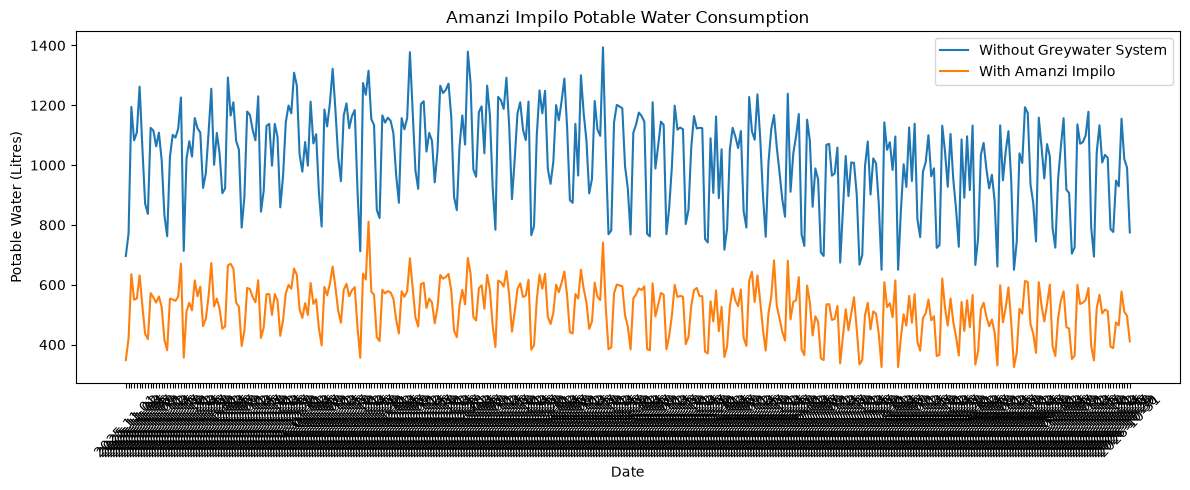

In [26]:
# Look at the water consumption 
# This graph is important for your project presentation because it visually demonstrates how much water consumption without and with system.
# Without there is a higher consumption With there is lower consumption of portable water
plt.figure(figsize=(12, 5))

plt.plot(
    water["date"],
    water["potable_before_l"],
    label="Without Greywater System"
)

plt.plot(
    water["date"],
    water["potable_after_l"],
    label="With Amanzi Impilo"
)

plt.xlabel("Date")
plt.ylabel("Potable Water (Litres)")
plt.title("Amanzi Impilo Potable Water Consumption")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
# Calculate total water saved get a number representing the synthetic 365-day saving
total_saved = water["potable_saved_l"].sum()

print("Total potable water saved:")
print(round(total_saved, 2), "litres p.a")

Total potable water saved:
185318.26 litres p.a


In [13]:
# Average daily potable water saved
average_daily_saved = water["potable_saved_l"].mean()

print(
    "Average daily potable water saved:",
    round(average_daily_saved, 2),
    "litres"
)

Average daily potable water saved: 507.72 litres


In [ ]:
# Now we train the FIRST ML model
# How many litres of potable water can be saved?
from sklearn.ensemble import RandomForestRegressor


In [15]:
# Loading features
X = pd.read_csv("02_water_savings_features.csv")

y = pd.read_csv("03_water_savings_target.csv")

y = y["potable_saved_l"]

In [16]:
# Check
print("Features:", X.shape)
print("Target:", y.shape)

Features: (365, 20)
Target: (365,)


In [ ]:
# Look at your ML features
# These are the things the model uses to make its prediction
X.head()

,day_of_year,month,day_of_week_num,site_users,season_index,nonpotable_demand_l,greywater_collected_l,greywater_recycled_l,recycling_efficiency,tank_average_l,valve_open_hours,pump_active_hours,ph,tds_mg_l,turbidity_ntu,temperature_c,maintenance_event,greywater_capture_ratio,reuse_to_demand_ratio,weekday
0,1,11,5,44,0.9679,617.27,675.89,618.01,0.9144,454.72,11.48,8.07,7.074,470.70,4.118,18.31,0,1.0932,0.9996,0
1,2,11,6,40,0.9691,460.32,470.20,388.21,0.8256,503.76,7.37,5.04,7.188,427.74,3.663,16.82,0,1.0192,0.8415,0
2,3,11,0,58,0.9704,647.25,809.32,700.01,0.8649,575.13,12.31,8.14,7.088,422.19,4.379,18.17,0,1.2485,1.0798,1
3,4,11,1,51,0.9717,599.47,767.00,648.70,0.8458,680.61,11.33,8.75,6.936,485.04,4.172,15.99,0,1.2773,1.0803,1
4,5,11,2,51,0.9730,652.41,724.07,628.92,0.8686,746.01,11.27,8.44,7.311,448.90,5.069,18.85,0,1.1081,0.9625,1


In [19]:
# Split training and testing data
X_train = pd.read_csv("04_water_savings_train_X.csv")
y_train = pd.read_csv("05_water_savings_train_y.csv")

X_test = pd.read_csv("06_water_savings_test_X.csv")
y_test = pd.read_csv("07_water_savings_test_y.csv")

y_train = y_train["potable_saved_l"]
y_test = y_test["potable_saved_l"]
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (292, 20)
Testing: (73, 20)


In [ ]:
# Train the model
# Now
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [29]:
#Then
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
# Lets make Make predictions
predictions = model.predict(X_test)
print("Predictions", predictions)

Predictions [455.97055 515.33605 380.16285 363.7971  491.05345 532.25455 472.06745
 508.5093  485.4942  375.4097  395.1747  519.4232  457.1561  563.4882
 499.032   564.32135 364.65715 372.4998  521.89705 495.6678  512.26455
 479.24545 498.12885 430.069   382.3607  521.28605 537.52045 496.611
 515.91615 503.76335 365.42605 381.07685 547.20645 528.5921  544.09735
 529.50805 493.6862  374.46715 384.30715 526.1989  504.94205 512.4447
 510.6695  483.43165 394.30925 400.08685 469.1535  492.0362  579.1764
 485.19155 466.8339  387.62655 355.6556  519.1038  536.27055 518.50705
 541.5429  577.9669  364.23485 369.06785 507.3848  537.3451  502.4385
 518.82965 529.09175 387.72755 380.79845 486.86045 530.50245 546.6841
 511.88805 516.94015 394.8703 ]


In [24]:
# Look at them:
#  the numbers show Predicted litres of potable water saved
predictions[:10]

array([455.97055, 515.33605, 380.16285, 363.7971 , 491.05345, 532.25455,
       472.06745, 508.5093 , 485.4942 , 375.4097 ])

In [25]:
# Compare prediction vs reality
results = pd.DataFrame({
    "actual_saved_l": y_test.values,
    "predicted_saved_l": predictions
})

results.head(10)

,actual_saved_l,predicted_saved_l
0,481.28,455.97055
1,494.63,515.33605
2,361.71,380.16285
3,366.10,363.79710
4,511.04,491.05345
5,522.71,532.25455
6,463.77,472.06745
7,550.16,508.50930
8,476.42,485.49420
9,426.38,375.40970


In [ ]:
#  Measure model accuracy
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# MAE Average prediction error in litres.
# means the model is approximately 25 litres away from the actual value on average
# RMSE Penalizes larger errors more heavily.
# R  Shows how much of the variation in water savings the model explains. closer to 1 better fit closer to 0 poor predictive perfomance

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21.822496575342498
RMSE: 26.915817678764178
R²: 0.861335903202183


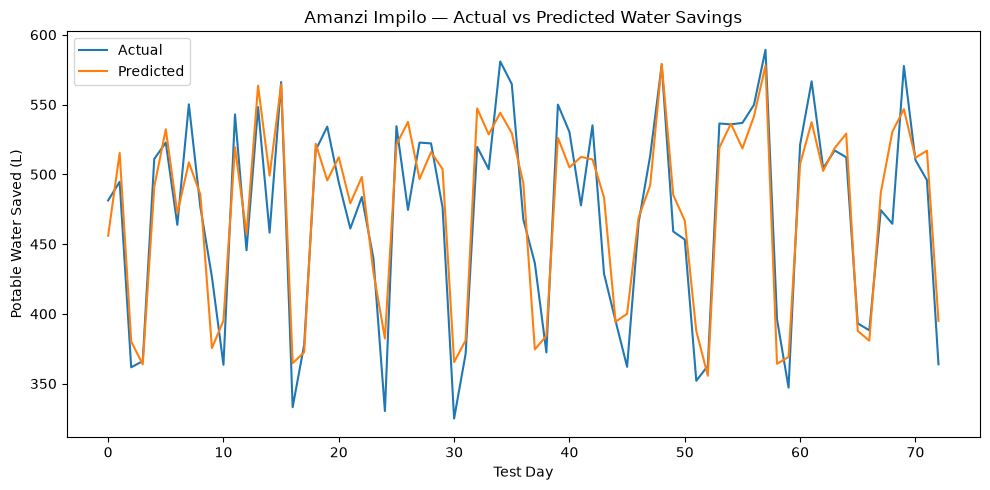

In [32]:
# Plot actual vs predicted
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.xlabel("Test Day")
plt.ylabel("Potable Water Saved (L)")
plt.title("Amanzi Impilo — Actual vs Predicted Water Savings")

plt.legend()
plt.tight_layout()

plt.show()

In [33]:
# Find which factors influence the prediction
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(10)

,feature,importance
2,day_of_week_num,0.236910
19,weekday,0.226669
3,site_users,0.213371
5,nonpotable_demand_l,0.072452
10,valve_open_hours,0.072070
11,pump_active_hours,0.039800
4,season_index,0.028159
15,temperature_c,0.018460
0,day_of_year,0.017694
6,greywater_collected_l,0.015321


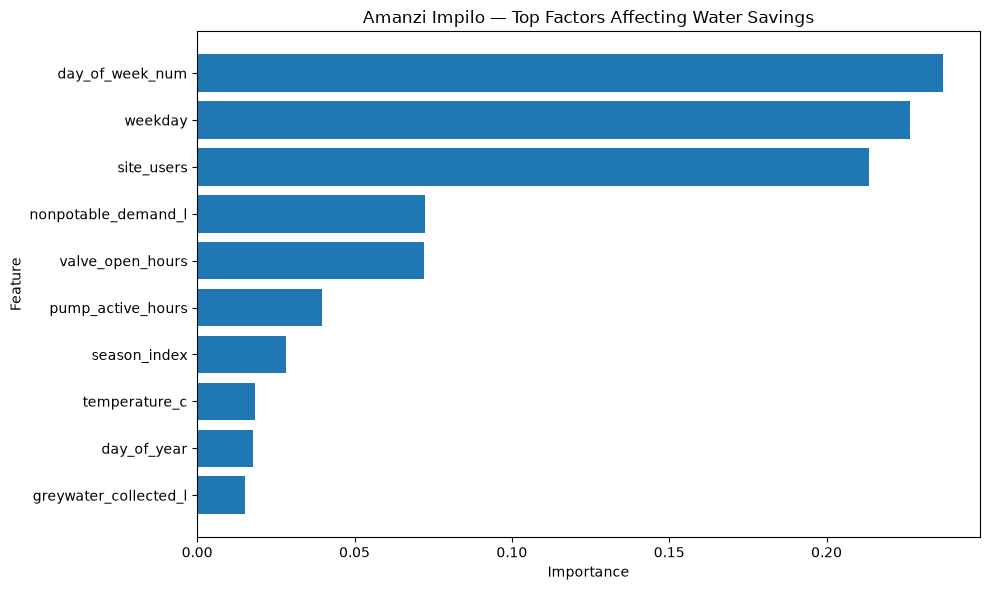

In [34]:
#  The machine-learning model identifies the variables that have the strongest relationship with predicted potable-water savings.
plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"].head(10),
    importance["importance"].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Amanzi Impilo — Top Factors Affecting Water Savings")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
# Calculate the annual prediction
# 
predicted_total = predictions.sum()

actual_total = y_test.sum()

print(
    "Predicted potable water saved:",
    round(predicted_total, 2),
    "L"
)

print(
    "Actual potable water saved:",
    round(actual_total, 2),
    "L"
)

Predicted potable water saved: 34704.72 L
Actual potable water saved: 34465.53 L
